# Pipeline related stuff

-e .
mne, mne_icalabel
ipykernel
onnxruntime
pyprep, meegkit

In [1]:
import mne
import os
from speed.pipeline_challenge import BasePipeline, PretrainPipeline
from pathlib import Path
import numpy as np

## preprocessing pipeline

In [3]:
# raw_path  = "/data/agjma/HBN_EEG_Raw/ds005505/sub-NDARAC904DMU/eeg/sub-NDARAC904DMU_task-RestingState_eeg.set" 
raw_path = "/scratch/linsk/tuh_test/aaaaabay/s001_2003_05_20/02_tcp_le/aaaaabay_s001_t000.edf"
assert os.path.exists(raw_path), f"File {raw_path} does not exist."
print(f"File {raw_path} exists.")

File /scratch/linsk/tuh_test/aaaaabay/s001_2003_05_20/02_tcp_le/aaaaabay_s001_t000.edf exists.


In [4]:
# load: 
raw = mne.io.read_raw_edf(raw_path, preload=True)

Extracting EDF parameters from /scratch/linsk/tuh_test/aaaaabay/s001_2003_05_20/02_tcp_le/aaaaabay_s001_t000.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 330249  =      0.000 ...  1320.996 secs...


In [5]:
raw.info['ch_names']

['EEG FP1-LE',
 'EEG FP2-LE',
 'EEG F3-LE',
 'EEG F4-LE',
 'EEG C3-LE',
 'EEG C4-LE',
 'EEG A1-LE',
 'EEG A2-LE',
 'EEG P3-LE',
 'EEG P4-LE',
 'EEG O1-LE',
 'EEG O2-LE',
 'EEG F7-LE',
 'EEG F8-LE',
 'EEG T3-LE',
 'EEG T4-LE',
 'EEG T5-LE',
 'EEG T6-LE',
 'EEG FZ-LE',
 'EEG CZ-LE',
 'EEG PZ-LE',
 'EEG OZ-LE',
 'EEG PG1-LE',
 'EEG PG2-LE',
 'EEG EKG-LE',
 'EEG SP2-LE',
 'EEG SP1-LE',
 'EEG 28-LE',
 'EEG 29-LE',
 'EEG 30-LE',
 'EEG T1-LE',
 'EEG T2-LE',
 'PHOTIC PH']

In [6]:
# raw = mne.io.read_raw_eeglab(raw_path, preload=True)
# print(raw.ch_names)
hbn_channels = ['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19', 'E20', 'E21', 'E22', 'E23', 'E24', 'E25', 'E26', 'E27', 'E28', 'E29', 'E30', 'E31', 'E32', 'E33', 'E34', 'E35', 'E36', 'E37', 'E38', 'E39', 'E40', 'E41', 'E42', 'E43', 'E44', 'E45', 'E46', 'E47', 'E48', 'E49', 'E50', 'E51', 'E52', 'E53', 'E54', 'E55', 'E56', 'E57', 'E58', 'E59', 'E60', 'E61', 'E62', 'E63', 'E64', 'E65', 'E66', 'E67', 'E68', 'E69', 'E70', 'E71', 'E72', 'E73', 'E74', 'E75', 'E76', 'E77', 'E78', 'E79', 'E80', 'E81', 'E82', 'E83', 'E84', 'E85', 'E86', 'E87', 'E88', 'E89', 'E90', 'E91', 'E92', 'E93', 'E94', 'E95', 'E96', 'E97', 'E98', 'E99', 'E100', 'E101', 'E102', 'E103', 'E104', 'E105', 'E106', 'E107', 'E108', 'E109', 'E110', 'E111', 'E112', 'E113', 'E114', 'E115', 'E116', 'E117', 'E118', 'E119', 'E120', 'E121', 'E122', 'E123', 'E124', 'E125', 'E126', 'E127', 'E128', 'Cz']
tuh_channels = ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'T7', 'C3', 'Cz', 'C4', 'T8', 'T5', 'P3', 'Pz', 'P4', 'T6', 'O1', 'O2']

In [7]:
# import logging

# logging.basicConfig(
#     level=logging.DEBUG,   # or INFO if you don’t want debug spam
#     format="%(asctime)s [%(levelname)s] %(message)s",
#     force=True             # overwrite any previous logging config
# )
# import sys
# logging.basicConfig(stream=sys.stdout, level=logging.DEBUG, force=True)


In [8]:
pipeline = PretrainPipeline(
    do_ica=False, 
    line_freqs=60, 
    channels_rename=None, 
    montage_name="tuh", 
    channels=tuh_channels, 
    window_length=30, 
    # metrics_path=Path("logs"), 
    hp_freq=0.5,
    lp_freq=50,
    return_quality_metrics=False,
    drop_bad_quality=True,
    )
# figure out none in window length


In [ ]:
raws, times, indices = pipeline([raw_path], )

# check manually if file looks okay: 


In [6]:
# load hdf5 file: 
import h5py
import numpy as np

data1_path = "/data/linsk/temp_prep/data_1.hdf5"

In [24]:
# load: 

with h5py.File(data1_path, 'r') as f:
    # print(dict(f.attrs).keys())
    data = f['data'][:]
    print(data.shape) # (windows, 105, 3000)
 

(9, 105, 3000)


In [27]:
data

array([[[ 2.00134055e-20,  1.44805244e-05,  1.34728825e-05, ...,
          1.46994589e-05,  1.60877225e-05,  1.98380417e-06],
        [-3.15384596e-22,  1.33157309e-05,  1.38136447e-05, ...,
          4.69458519e-06,  2.26258203e-06, -1.18991989e-06],
        [ 1.49312078e-20,  1.46803877e-05,  1.41605506e-05, ...,
          3.85167505e-06,  1.97497229e-06, -2.29800708e-06],
        ...,
        [-8.78571389e-21,  9.45357715e-06,  8.46508465e-06, ...,
          6.66753749e-06,  3.98024849e-06,  4.95227937e-07],
        [-7.09164800e-21,  1.13274536e-05,  1.13050128e-05, ...,
          4.94765482e-06,  3.17593435e-06, -1.82682777e-06],
        [ 1.90032338e-20, -1.37538755e-05, -8.42568897e-06, ...,
          8.73489114e-07, -1.65053154e-06,  7.26436156e-07]],

       [[ 6.19335934e-21, -1.96639467e-05, -2.67417345e-05, ...,
          7.71255236e-06, -5.11013059e-06, -3.34108472e-06],
        [-9.90026707e-21, -7.63022126e-06, -1.26296627e-05, ...,
          4.67340124e-06, -2.55359760e

Creating RawArray with float64 data, n_channels=105, n_times=3000
    Range : 0 ... 2999 =      0.000 ...    29.990 secs
Ready.


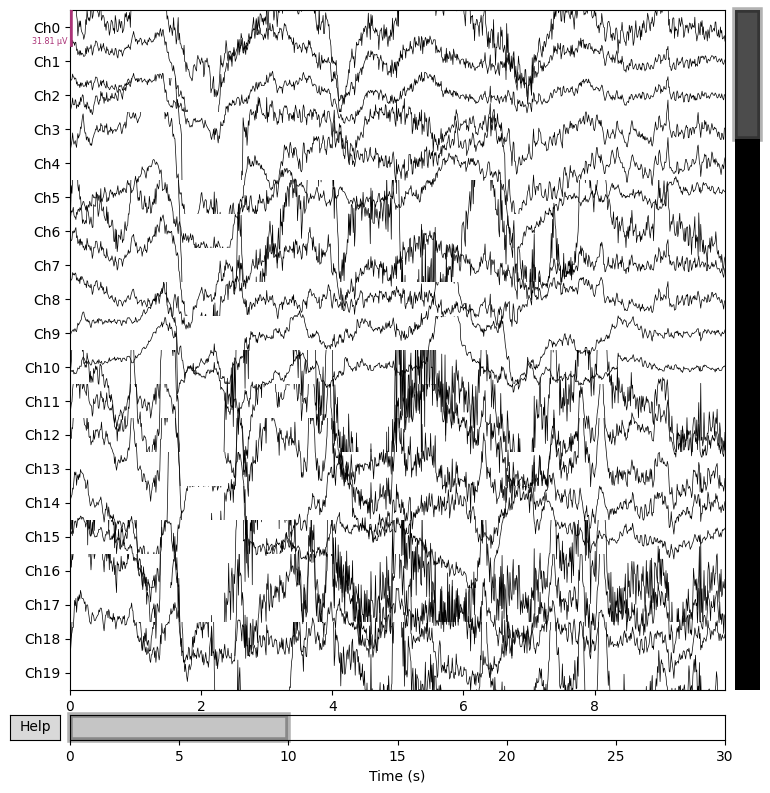

''

In [32]:
import mne

window_idx = 0
eeg_data = data[window_idx] 

sfreq = 100 
ch_names = [f"Ch{i}" for i in range(eeg_data.shape[0])]
ch_types = ["eeg"] * eeg_data.shape[0]

info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)
raw = mne.io.RawArray(eeg_data, info)

raw.plot(scalings='auto', title=f"Window {window_idx}", show=True)
;


# Align montages: 


In [22]:
from mne.channels import make_dig_montage
from speed.utils import  make_tuh_montage
from speed.methods import PreprocessMethods

In [23]:
raw_path_hbn  = "/scratch/linsk/hbn_test/sub-NDARAC904DMU/eeg/sub-NDARAC904DMU_task-RestingState_eeg.set"
raw_path_tuh = "/scratch/linsk/tuh_test/aaaaabay/s001_2003_05_20/02_tcp_le/aaaaabay_s001_t000.edf"

raw_hbn = mne.io.read_raw_eeglab(raw_path_hbn, preload=True)
raw_tuh = mne.io.read_raw_edf(raw_path_tuh, preload=True)

Extracting EDF parameters from /scratch/linsk/tuh_test/aaaaabay/s001_2003_05_20/02_tcp_le/aaaaabay_s001_t000.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 330249  =      0.000 ...  1320.996 secs...


In [24]:
def get_channel_positions(raw):
    """Return a dict {ch_name: xyz} for channels that have locations."""
    positions = {}
    for ch in raw.info['chs']:
        ch_name = ch['ch_name']
        loc = ch['loc'][:3]  # first 3 elements are x, y, z
        if np.any(loc):  # skip if all zeros
            positions[ch_name] = loc
    return positions

In [25]:
positions_hbn = {ch: pos for ch, pos in get_channel_positions(raw_hbn).items()}
montage_hbn = make_dig_montage(ch_pos=positions_hbn, coord_frame='head')
montage_gsn = mne.channels.make_standard_montage('GSN-HydroCel-128')
montage_10_20 = mne.channels.make_standard_montage('standard_1020')

montage_tuh = make_tuh_montage()
PreprocessMethods.to_standard_names(raw_tuh)
PreprocessMethods.set_montage(raw_tuh, montage_tuh);

In [26]:
# raw = raw_tuh.interpolate_to(sensors=montage, method='spline') # no bc to 128 not just minimally 

### interpolation?

In [27]:
import numpy as np

def interpolate_by_location(raw_small, raw_large, tol=1e-6):
    """
    Interpolates channel positions from a smaller montage to a larger one.
    
    Parameters:
    - raw_small: MNE Raw object with fewer channels
    - raw_large: MNE Raw object with full set of channels
    - tol: tolerance for matching channel positions
    
    Returns:
    - ch_locs_new: dict of channel positions for raw_small
    - matched_channels: list of channels with exact matches
    - interpolated_channels: list of channels that were interpolated
    """
    pos_small = np.array([raw_small.info['chs'][raw_small.info['ch_names'].index(ch)]['loc'][:3]
                          for ch in raw_small.info['ch_names']])
    pos_large = np.array([raw_large.info['chs'][raw_large.info['ch_names'].index(ch)]['loc'][:3]
                          for ch in raw_large.info['ch_names']])
    
    names_small = raw_small.info['ch_names']
    names_large = raw_large.info['ch_names']

    ch_locs_new = {}
    matched_channels = []
    interpolated_channels = []
    interpolated_to =[]

    for i, p in enumerate(pos_small):
        dists = np.linalg.norm(pos_large - p, axis=1)
        if np.any(dists < tol):
            # Exact match
            ch_locs_new[names_small[i]] = pos_large[np.argmin(dists)]
            matched_channels.append(names_small[i])
        else:
            # Map to nearest large-channel position (interpolation)
            nearest_idx = np.argmin(dists)
            ch_locs_new[names_small[i]] = pos_large[nearest_idx]

            interpolated_channels.append(names_small[i])
            interpolated_to.append(names_large[nearest_idx])

    print("Matched channels:", matched_channels)
    print("Interpolated channels:", interpolated_channels)
    print("Interpolated to:", interpolated_to)
    print(f"Counts -> Matched: {len(matched_channels)}, Interpolated: {len(interpolated_channels)}")

    return ch_locs_new, matched_channels, interpolated_channels, interpolated_to


In [28]:
interpolate_by_location(raw_tuh, raw_hbn )

Matched channels: []
Interpolated channels: ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'A1', 'A2', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T7', 'T8', 'T5', 'T6', 'Fz', 'Cz', 'Pz', 'Oz', 'T1', 'T2']
Interpolated to: ['E18', 'E10', 'E19', 'E4', 'E30', 'E105', 'E44', 'E114', 'E53', 'E86', 'E67', 'E77', 'E27', 'E123', 'E40', 'E109', 'E47', 'E98', 'E12', 'E7', 'E55', 'E72', 'E33', 'E122']
Counts -> Matched: 0, Interpolated: 24


({'Fp1': array([-0.01830882,  0.08708839,  0.03187091]),
  'Fp2': array([0.01830882, 0.08708839, 0.03187091]),
  'F3': array([-0.02868838,  0.07145709,  0.04989565]),
  'F4': array([0.02868838, 0.07145709, 0.04989565]),
  'C3': array([-0.03695491,  0.00960411,  0.07627828]),
  'C4': array([0.03695491, 0.00960411, 0.07627828]),
  'A1': array([-0.06840718,  0.01278489, -0.03555382]),
  'A2': array([ 0.06840718,  0.01278489, -0.03555382]),
  'P3': array([-0.04193519, -0.0403702 ,  0.0698292 ]),
  'P4': array([ 0.04193519, -0.0403702 ,  0.0698292 ]),
  'O1': array([-0.01844644, -0.07354417,  0.05224002]),
  'O2': array([ 0.01844644, -0.07354417,  0.05224002]),
  'F7': array([-0.05682548,  0.05453384,  0.02836565]),
  'F8': array([0.05682548, 0.05453384, 0.02836565]),
  'T7': array([-0.07391919,  0.00032152,  0.02143635]),
  'T8': array([0.07391919, 0.00032152, 0.02143635]),
  'T5': array([-0.06737314, -0.0301182 ,  0.0417839 ]),
  'T6': array([ 0.06737314, -0.0301182 ,  0.0417839 ]),
  'Fz

In [29]:
# join to one
# the idea: 

# 1. get closest positions in hbn 
# 2. pass it to pipeline
# 3. need double montage? 


In [30]:
Interpolated_tuh = ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'A1', 'A2', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T7', 'T8', 'T5', 'T6', 'Fz', 'Cz', 'Pz', 'Oz', 'T1', 'T2']
Interpolated_hbn = ['E18', 'E10', 'E19', 'E4', 'E30', 'E105', 'E44', 'E114', 'E53', 'E86', 'E67', 'E77', 'E27', 'E123', 'E40', 'E109', 'E47', 'E98', 'E12', 'E7', 'E55', 'E72', 'E33', 'E122']

In [31]:
# get positions: 
positions_tuh = {ch: pos for ch, pos in get_channel_positions(raw_tuh).items()}
positions_hbn = {ch: pos for ch, pos in get_channel_positions(raw_hbn).items()}


In [32]:
combined_pos = {**{f"{ch}_t": pos for ch, pos in positions_tuh.items() if ch in Interpolated_tuh}, **{f"{ch}_h": pos for ch, pos in positions_hbn.items() if ch in Interpolated_hbn}}

In [33]:
combined_pos

{'Fp1_t': array([-0.03090259,  0.11458518,  0.02786657]),
 'Fp2_t': array([0.0284095 , 0.11534631, 0.02772126]),
 'F3_t': array([-0.05180904,  0.0866879 ,  0.07871409]),
 'F4_t': array([0.05027428, 0.08743839, 0.07727065]),
 'C3_t': array([-0.06714872,  0.02335823,  0.10451068]),
 'C4_t': array([0.06532888, 0.0235731 , 0.10369243]),
 'A1_t': array([-0.08794078,  0.00260136, -0.02686454]),
 'A2_t': array([ 0.08392806,  0.00196781, -0.02690846]),
 'P3_t': array([-0.05503823, -0.0442103 ,  0.09990898]),
 'P4_t': array([ 0.05363602, -0.04433452,  0.10051603]),
 'O1_t': array([-0.03157356, -0.08056835,  0.05478965]),
 'O2_t': array([ 0.0276831 , -0.08048884,  0.05473408]),
 'F7_t': array([-0.07187663,  0.07310353,  0.02579046]),
 'F8_t': array([0.07143527, 0.07450513, 0.02510103]),
 'T7_t': array([-0.08598208,  0.01487164,  0.03117337]),
 'T8_t': array([0.08326137, 0.01525819, 0.03097297]),
 'T5_t': array([-0.07445796, -0.04212316,  0.04127363]),
 'T6_t': array([ 0.07103247, -0.04225998,  0

In [34]:
combined_montage = mne.channels.make_dig_montage(ch_pos=combined_pos, coord_frame='head')


### montage plots

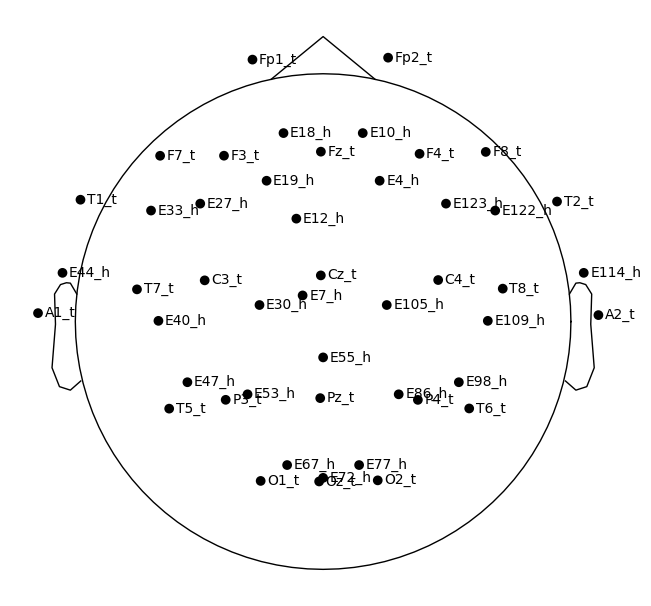

In [52]:
combined_montage.plot();

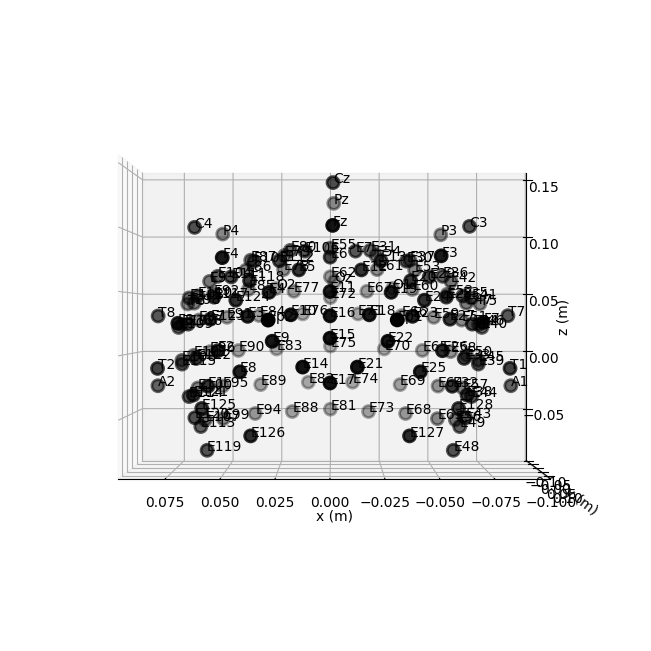

Text(0.5, 0.98, 'Combined Montage (20 + 20 channels)')

In [30]:
    fig = combined_montage.plot(kind='3d', show_names=True)
    fig.suptitle("Combined Montage (20 + 20 channels)", fontsize=14)

In [35]:
import mne
import matplotlib.pyplot as plt
import numpy as np

def plot_two_montages_2d(montage1, montage2, color1='blue', color2='red'):
    pos1 = montage1.get_positions()['ch_pos']
    pos2 = montage2.get_positions()['ch_pos']

    fig, ax = plt.subplots(figsize=(6, 6))

    # Montage 
    # Montage 1
    for ch, pos in pos1.items():
        ax.scatter(pos[0], pos[1], color=color1, label='Montage 1' if ch == list(pos1.keys())[0] else "", alpha=0.7)
        ax.text(pos[0], pos[1], ch, fontsize=8, color=color1, ha='center')

    # Montage 2
    for ch, pos in pos2.items():
        ax.scatter(pos[0], pos[1], color=color2, label='Montage 2' if ch == list(pos2.keys())[0] else "", alpha=0.7)
        ax.text(pos[0], pos[1], ch, fontsize=8, color=color2, ha='center')

    ax.legend()
    ax.set_title("Overlay of Two Montages (2D projection)")
    ax.set_xlabel("X position")
    ax.set_ylabel("Y position")
    ax.axis('equal')
    plt.show()



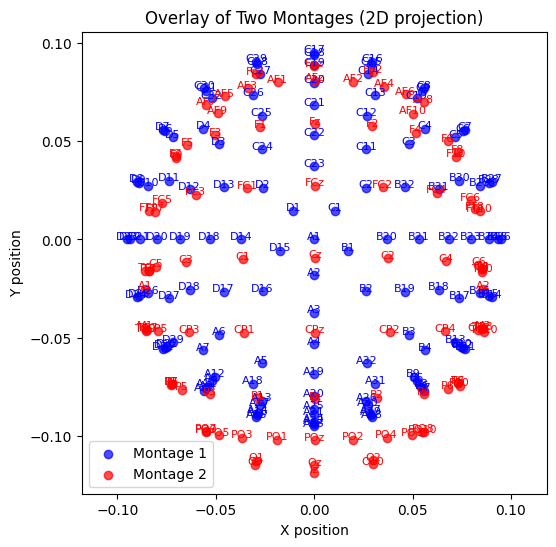

In [36]:
montage1 = mne.channels.make_standard_montage("biosemi128")
montage2 = mne.channels.make_standard_montage("standard_1020")

plot_two_montages_2d(montage1, montage2, color1='blue', color2='red')


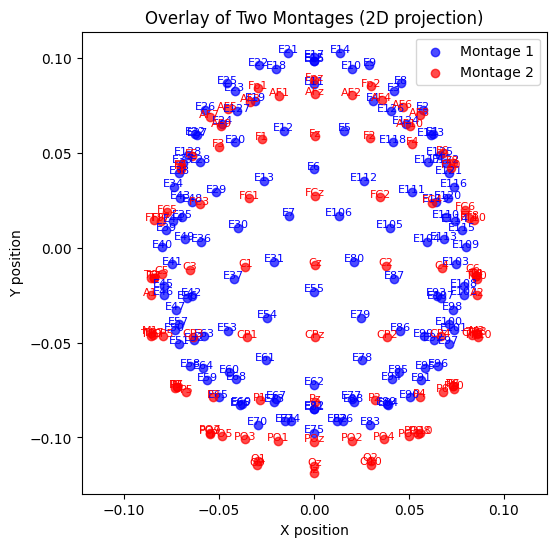

In [37]:
montage1 = mne.channels.make_standard_montage("GSN-HydroCel-128")
montage2 = mne.channels.make_standard_montage("standard_1020")

plot_two_montages_2d(montage1, montage2, color1='blue', color2='red')

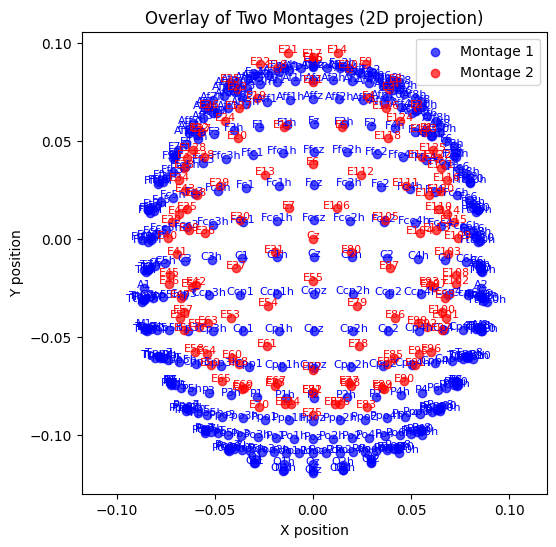

In [55]:
plot_two_montages_2d(montage_tuh, montage_hbn, color1='blue', color2='red')

In [ ]:
how does tuh and gsn compare? ie maybe go from hbn to gsl and then pick? 

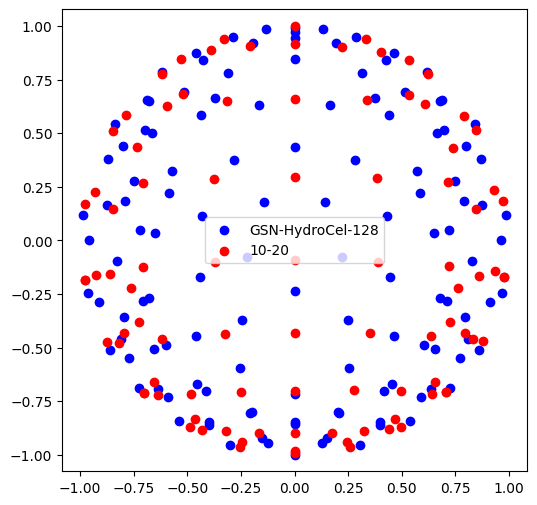

In [38]:
import mne
import numpy as np
import matplotlib.pyplot as plt

def plot_two_montages_2d_unit(montage1, montage2, color1='blue', color2='red'):
    # get positions
    pos1 = np.array(list(montage1.get_positions()['ch_pos'].values()))
    pos2 = np.array(list(montage2.get_positions()['ch_pos'].values()))
    
    # normalize to unit vectors (remove scale)
    pos1_uv = pos1 / np.linalg.norm(pos1, axis=1)[:, None]
    pos2_uv = pos2 / np.linalg.norm(pos2, axis=1)[:, None]
    
    # project to 2D (simple orthographic)
    def proj(xyz):
        return xyz[:, 0], xyz[:, 1]
    
    x1, y1 = proj(pos1_uv)
    x2, y2 = proj(pos2_uv)
    
    plt.figure(figsize=(6,6))
    plt.scatter(x1, y1, c=color1, label='GSN-HydroCel-128')
    plt.scatter(x2, y2, c=color2, label='10-20')
    plt.axis('equal')
    plt.legend()
    plt.show()

# Example usage
montage1 = mne.channels.make_standard_montage("GSN-HydroCel-128")
montage2 = mne.channels.make_standard_montage("standard_1020")
plot_two_montages_2d_unit(montage1, montage2)


In [ ]:
#normalize, pick nearest and then plot???

## gg

In [8]:
raw_hbn.montage

AttributeError: 'RawEEGLAB' object has no attribute 'montage'

4 duplicate electrode labels found:
T7/T3, T8/T4, P7/T5, P8/T6
Plotting 90 unique labels.


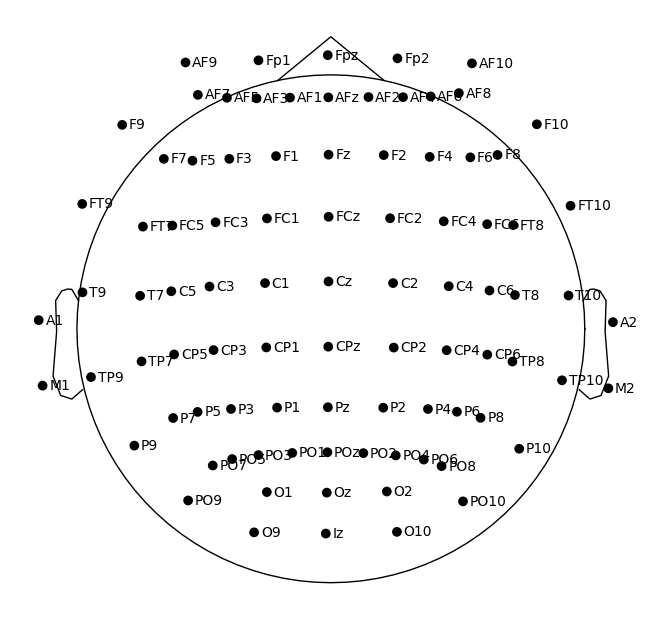

In [13]:
ten20 = mne.channels.make_standard_montage('standard_1020')
ten20.plot();

In [10]:
gsn = mne.channels.make_standard_montage('GSN-HydroCel-128')

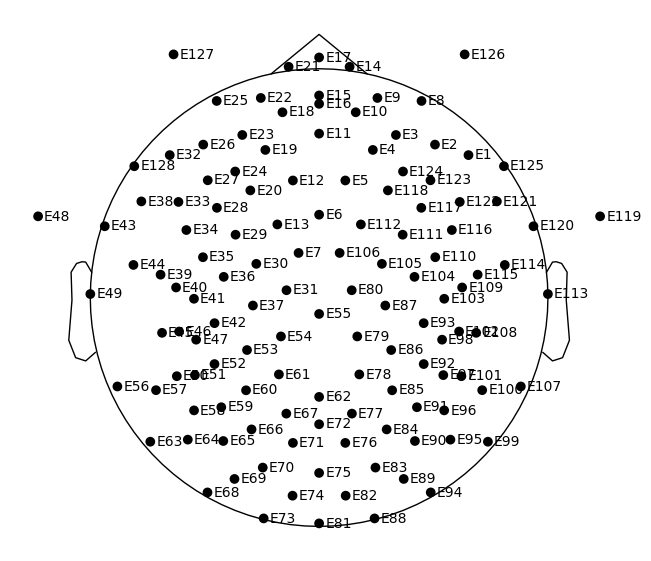

In [11]:
gsn.plot();

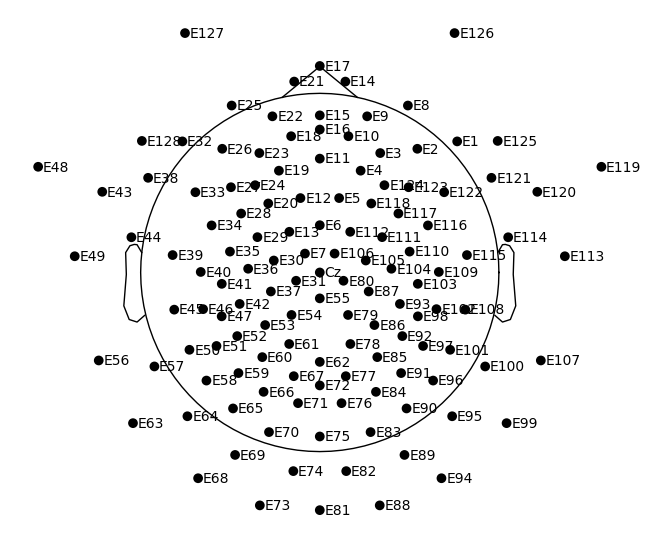

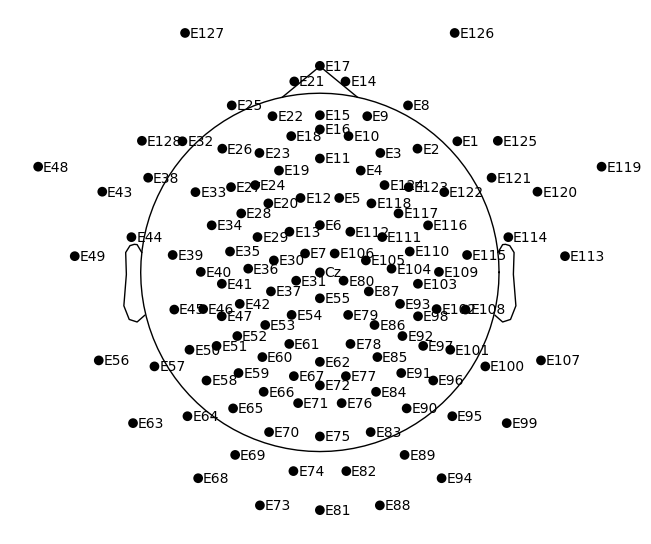

In [12]:
montage_hbn.plot()

In [19]:
import numpy as np
import mne
from scipy.spatial import cKDTree

# load montages
gsn = mne.channels.make_standard_montage('GSN-HydroCel-128')   # GSN positions (dict ch_pos)
ten20 = mne.channels.make_standard_montage('standard_1020')   # 10-20 positions

# get ch_pos dict -> arrays (in meters)
gsn_pos = gsn.get_positions()['ch_pos']
ten20_pos = ten20.get_positions()['ch_pos']

gsn_names = np.array(list(gsn_pos.keys()))
gsn_xyz = np.vstack([gsn_pos[n] for n in gsn_names])

t20_names = np.array(list(ten20_pos.keys()))
t20_xyz = np.vstack([ten20_pos[n] for n in t20_names])

# normalize to unit vectors (compare angular distances on sphere)
gsn_uv = gsn_xyz / np.linalg.norm(gsn_xyz, axis=1)[:, None]
t20_uv  = t20_xyz  / np.linalg.norm(t20_xyz, axis=1)[:, None]

# KD-tree on unit vectors: find nearest 10-20 label for each GSN channel
# tree = cKDTree(t20_uv)
# dists, idx = tree.query(gsn_uv, k=1)
tree = cKDTree(gsn_uv)
dists, idx = tree.query(t20_uv , k=1)

# convert chord distance -> angle in degrees
angles_deg = np.degrees(2 * np.arcsin(np.clip(dists / 2, 0, 1)))

# build mapping with threshold (example 15 degrees)
threshold_deg = 15.0
mapping = {}
for i, gname in enumerate(t20_names ): # gsn_names
    if i >= len(idx):  # skip if out of range
        continue
    try:
        tname = gsn_names[idx[i]]
    except IndexError:
        tname = None
    ang = angles_deg[i] if i < len(angles_deg) else np.nan
    mapping[gname] = (tname if tname and ang <= threshold_deg else None, ang)


In [20]:
mapping

{np.str_('Fp1'): (np.str_('E25'), np.float64(9.349738138884822)),
 np.str_('Fpz'): (np.str_('E14'), np.float64(8.808174505774815)),
 np.str_('Fp2'): (np.str_('E8'), np.float64(9.298393431115002)),
 np.str_('AF9'): (np.str_('E127'), np.float64(11.89158835570275)),
 np.str_('AF7'): (np.str_('E26'), np.float64(8.946043090866427)),
 np.str_('AF5'): (np.str_('E26'), np.float64(6.597533054548895)),
 np.str_('AF3'): (np.str_('E23'), np.float64(6.300530248816986)),
 np.str_('AF1'): (np.str_('E18'), np.float64(2.326298252914606)),
 np.str_('AFz'): (np.str_('E16'), np.float64(4.791242599832063)),
 np.str_('AF2'): (np.str_('E10'), np.float64(2.665653444767608)),
 np.str_('AF4'): (np.str_('E3'), np.float64(5.7174346674232055)),
 np.str_('AF6'): (np.str_('E2'), np.float64(6.289748890810655)),
 np.str_('AF8'): (np.str_('E2'), np.float64(8.943535326008856)),
 np.str_('AF10'): (np.str_('E126'), np.float64(12.357169379259297)),
 np.str_('F9'): (np.str_('E128'), np.float64(5.1427531851281545)),
 np.str_

In [21]:
len(mapping)

94